In [2]:
import pandas as pd
import random
import numpy as np
np.float_ = np.float64
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from danrerlib import mapping, utils

data_path = '/Volumes/CSDG/Daniel_Gray/Daniel_scRNA_seq/Lawson_map_combined/all-sample/DGE_filtered/'
out_path = '/Volumes/CSDG/Daniel_Gray/Daniel_scRNA_seq/Pseudobulk/'

In [3]:
import warnings
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [4]:
adata = sc.read(data_path + 'labelled.h5ad')

In [9]:
adata

AnnData object with n_obs × n_vars = 82724 × 31148
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', '_scvi_batch', '_scvi_labels', 'doublet_x', 'singlet_x', 'prediction_x', 'doublet_y', 'singlet_y', 'prediction_y', 'genotype', 'batch', 'ref5_label', 'ref5_score', 'ref10_label', 'ref10_score', 'predicted', 'transfer_score', 'overcluster', 'ref_label', 'CellType', 'CellTypeMajor'
    var: 'gene_id', 'genome', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'CellTypeMajor_colors', 'CellType_colors', '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'log1p', 'neighbors', 'overcluster_colors', 'pca', 'predicted_col

In [6]:
adata.obs['sample'].value_counts()

sample
Wts-3    19646
R21-3    17148
R21-2    10597
Wik-2     9682
S2b-3     8619
Wts-2     7069
Wik-3     5981
S2b-2     3982
Name: count, dtype: int64

In [7]:
cell_subset = adata[adata.obs["CellTypeMajor"] == "Neural"]
sc.tl.umap(cell_subset)

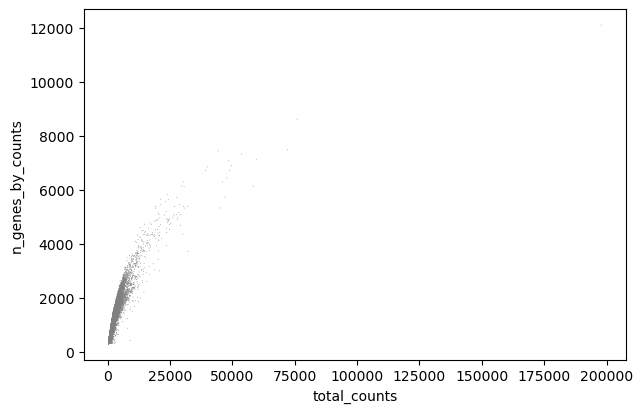

median transcript count per cell: 1253.0
median gene count per cell: 766.0
median mito percentage per cell: 0.04847897216677666


In [13]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', save='_gene_vs_transcript_counts')
print('median transcript count per cell: ' + str(adata.obs['tscp_count'].median(0)))
print('median gene count per cell: ' + str(adata.obs['gene_count'].median(0)))
print('median mito percentage per cell: ' + str(adata.obs['pct_counts_mt'].median(0)))

## Setting neural cell types fine

In [ ]:
sc.tl.leiden(cell_subset, resolution = 2, key_added = 'overcluster')

In [ ]:
sc.tl.rank_genes_groups(cell_subset, groupby = 'overcluster')
marks = sc.get.rank_genes_groups_df(cell_subset, group = None)

In [ ]:
sc.pl.umap(cell_subset, color = ['overcluster'], s = 1,legend_loc = 'on data',legend_fontsize=6)

In [ ]:
num='37'
ax = sc.pl.umap(cell_subset, palette = 'lightgrey', show = False)
sc.pl.umap(cell_subset[cell_subset.obs.overcluster == num], color = 'overcluster', ax = ax, legend_loc = 'on data', palette = 'k', alpha=0.01)

In [ ]:
topmarks=marks.names[(marks.group == num)].head(25)
sc.pl.umap(cell_subset, color=[i for i in topmarks], color_map='turbo', legend_fontsize=8, legend_loc = 'on data', s = 5)

In [ ]:
# genes which are also in the HCR atlas
#gene_list = ['aldh1a2','ascl1b','cabp5b','calb1','calb2a','calb2b','calca','cart2','cart3','chata']
#gene_list = ['cort','dbh','emx2','eomesa','fabp7a','fat2','gad1a','gbx2','isl1','isl2b']
#gene_list = ['mafaa','mef2cb','neurod2','nfia','npb','npy','otpa','pax7a','pcna','pou4f2']
#gene_list = ['pth2','pth2r','pyya','pyyb','satb2','slc6a3','slc6a5','slc6a9','slc17a6a','slc17a7a']
#gene_list = ['sox7','sst1.2','tbr1b','tbx20','th','th2','tph2','vsx1','zbtb18','zic4']


# EXAMPLE
gene_list = ['','','','']
#gene_list = ['','','','','','','','']
sc.pl.umap(cell_subset, color=[i for i in gene_list], color_map='turbo', legend_fontsize=8, legend_loc = 'on data', s = 5)

In [ ]:
over2cell = {
"0":"Neuron", # HB-Glyt2
"1":"Neuron", # GABA
"2":"HB", #
"3":"Proliferative Glia",  #pcna,fabpza,
"4":"NS", # some elavl3
"5":"Tectum", # emx2,gad1a
"6":"Thalamus Proper", # pou4f2, lef1, lhx9
"7":"NS", # not neuronal krt etc. Possibly doublets, super low tscp counts
"8":"Neuron", #
"9":"HB", #
"10":"Neuron", #
"11":"FB-GABA", #
"12":"Torus Longitudinalis", # fat2,neurod2
"13":"Tectum", # pax7a
"14":"OSN-Glut", #
"15":"MB-Diff", # pou4f2, nfia, nfixb (looks proliferative or recently differentiated
"16":"HB", # otpa
"17":"Oculo-motor", # chata, isl1a
"18":"Perivent-layer", # pou4f2,tfap2a/b could be more
"19":"Neuron-Diff", # pou4f2,tfap2a/b could be more
"20":"Tectum", # emx2,gad1a,pax7a
"21":"Perivent-layer", # pou4f2,tfap2a/b
"22":"Pallium-Diff", #
"23":"HB", # HB-Glyt2
"24":"MHBB-Diff", #pax5,lhx9
"25":"Sensory", # eya1
"26":"Tectum", # emx2,gad1a,pax7a
"27":"PNS-NS", # Includes facial motor?, and enteric neurons (th, vipb, vip)
"28":"Pallium", # neurod2,eomesa,tbr1b
"29":"MHBB-Diff", #
"30":"HB", #
"31":"Serotonergic", #
"32":"Dorsal Habenula", # pou4f2,zic4
"33":"Perivent-layer", # pou4f2, could be more
"34":"Olfactory-interneuron", # Only region identified with overlapping expression of sl17a6a,sl17a6b,gad1b, mef2cb, nfia, probably a combination of periglomerular cells (GABA), and mitral cells (glutamatergic)
"35":"Neuron-Diff", # sl17a6a(glut)+lhx9(diff), with all the other differentiating cells
"36":"Oligodendrocyte", # mbpa (myelinating), gldn, cldn19
"37":"Sensory", # eya1,eya4,asic1c
"38":"Tectum", # emx2,gad1a,pax7a
"39":"Pallium", # eomesa, tbr1b
"40":"UNK", # kcnj19a, grm2a
"41":"Sensory-Diff", # nes, neurod1, ccnd2a, mvp, foxp4 (could be prog)
"42":"Oligodendrocyte", #
"43":"Cerebellum-diff", # foxp4, rorb, esrrb
"44":"UNK", #
"45":"Neuron", # esrrb, (probably cerebellum)
"46":"ak5-Neuron", # prkcq, ak5, plekhg5b, ngfra
"47":"Trochlear-motor", # chata,
"48":"UNK", #
"49":"HB", # otpa
"50":"Oligodendrocyte", #
"51":"Melanocytes", #
"52":"Cerebellum", # eomesa, zic2a
"53":"Oligodendrocyte", # bcan
"54":"Proliferative Glia", # glula
"55":"UNK", #
"56":"Muller glia", #
"57":"UNK", #
"58":"UNK", # elavl3, tbx3a, pax6b
"59":"Oligodendrocyte", #
"60":"Olfactory-epi", #
"61":"Olfactory-epi", #
"62":"Proliferative Glia", #
"63":"UNK", # lmx1al, lmx1ba
"64":"UNK", #
}

In [ ]:
cell_subset.obs['celltypefine'] = cell_subset.obs.overcluster.map(over2cell)

In [ ]:
# habenula
#gene_list = ['pou4f2','zic4','pax7a']
# hindbrain
#gene_list = ['slc6a5','slc6a9','tbx20']
# Olfactory
#gene_list = ['pvalb5','s100z','cldnh','gng13b','tspan2a','txn','epcam']
# GABAergic (first) / Glutamatergic (second2)
#gene_list = ['gad1b','slc17a6a','slc17a6b','elavl3']
# Forebrain prog/diff/inh
#gene_list = ['sox1b','dlx2a']
# optic tectum
#gene_list = ['gata2a','gata3','sox14','gad1b','ptmaa','slc6a1b','tal1','id2b']
# Hindbrain
#gene_list = ['hoxb5b','hoxb5a','hoxb6a','hoxb6b','hoxb3a','hoxc4a']
# diencephalon dorsal, thalamus [glutamatergic]
#gene_list = ['lhx9','lef1','barhl1a','barhl1b','barhl2','slc17a6a','slc17a6b','lhx9']
# Telencephalon
#gene_list = ['zic1','zic4','foxg1a','gsx2','tbr1b','eomesa','draxin','emx3']
# Gabaergic/Glutamatergic/Glycinergic/
#gene_list = ['gad2','slc17a6a','slc17a6b','elavl3']
# supposedly dopaminergic/seratonergic
#gene_list = ['slc6a2','th2']
#neuroblast
#gene_list = ['neurod2', 'neurod1', 'sox2', 'dla','ebf2','pcna','ascl1a','ascl1b']

#g1s markers
#gene_list = ['mcm5', 'pcna', 'tyms', 'mcm7', 'mcm4', 'rrm1', 'gins2', 'mcm6', 'dtl', 'prim1', 'uhrf1', 'hells', 'cdc6', 'rfc2', 'polr1b', 'rad51ap1', 'wdr76', 'slbp', 'msh2', 'atad2', 'rad51', 'rrm2', 'cdc45', 'tipin', 'dscc1', 'usp1', 'pola1', 'chaf1b', 'mrpl36', 'e2f8']
# g2m markers
#gene_list = ['cdk1', 'top2a', 'tpx2', 'nuf2', 'mki67', 'tacc3', 'cenpf', 'smc4', 'kif11', 'ndc80', 'cks1b', 'ccnb2', 'ckap2l', 'aurkb', 'bub1', 'gtse1', 'cdc20', 'ttk', 'kif2c', 'ncapd2', 'dlgap5', 'cdca8', 'ect2', 'kif23', 'hmmr', 'anln', 'lbr', 'cenpe', 'g2e3']

# pcdh2a
#gene_list = ['','','','','','','','']
# pcdh1g
#gene_list = ['','','','','','','','']

gene_list = ['elavl3']
#gene_list = ['','','','','','','','']
sc.pl.umap(cell_subset, color=[i for i in gene_list], color_map='viridis', legend_fontsize=8, legend_loc = 'on data', s = 5)

## Looking at neural cell types fine

In [ ]:
sc.pl.umap(cell_subset, color = ['celltypefine'], s = 1,legend_loc = 'on data',legend_fontsize=6, save = 'neuralcelltypefine_labelled.pdf')

In [ ]:
sc.pl.umap(adata, color = ['CellTypeMajor'], s = 1,legend_loc = 'on data',legend_fontsize=6, save = 'celltypemajor_labelled.pdf')

In [ ]:
adata

In [ ]:
sc.pl.umap(adata, color = ['CellType'], s = 1,legend_loc = 'on data',legend_fontsize=6, save = 'celltypefine_labelled.pdf')

In [ ]:
sc.pl.umap(cell_subset, color = ['tscp_count'], s = 1, legend_fontsize=6, save = 'labelled', color_map='turbo')

In [ ]:
#cell_subset.write_h5ad(data_path + 'neuralrelabelled_9_10_25.h5ad')

## Cell cycle phases

In [ ]:
# taken the cell cylce genes from Single-cell analysis of shared signatures and transcriptional diversity during zebrafish development
# https://www.sciencedirect.com/science/article/pii/S1534580723005774?via%3Dihub#mmc1

#g1s markers

# g2m markers
#gene_list = ['cdk1', 'top2a', 'tpx2', 'nuf2', 'mki67', 'tacc3', 'cenpf', 'smc4', 'kif11', 'ndc80', 'cks1b', 'ccnb2', 'ckap2l', 'aurkb', 'bub1', 'gtse1', 'cdc20', 'ttk', 'kif2c', 'ncapd2', 'dlgap5', 'cdca8', 'ect2', 'kif23', 'hmmr', 'anln', 'lbr', 'cenpe', 'g2e3']


g1s_genes = ['mcm5', 'pcna', 'tyms', 'mcm7', 'mcm4', 'rrm1', 'gins2', 'mcm6', 'dtl', 'prim1', 'uhrf1',
            'hells', 'ccne2', 'cdc6', 'rfc2', 'polr1b', 'nasp', 'rad51ap1', 'wdr76', 'slbp', 
            'pold3', 'msh2', 'atad2', 'rad51', 'rrm2', 'cdc45', 'tipin', 'dscc1', 'usp1', 
            'pola1', 'chaf1b', 'mrpl36', 'e2f8']
           
g2m_genes = ['cdk1', 'ube2c', 'top2a', 'tpx2', 'cks2', 'nuf2', 'mki67', 'tacc3', 'cenpf', 'smc4',
             'ckap4', 'kif11', 'ndc80', 'cks1b', 'ccnb2', 'ckap2l', 'aurkb', 'bub1',
             'gtse1', 'cdc20', 'ttk', 'kif2c', 'ncapd2', 'dlgap5', 'cdca8',
             'ect2', 'kif23', 'hmmr', 'aurka', 'anln', 'lbr', 'cenpe', 'nek2', 'g2e3']
sc.tl.score_genes_cell_cycle(cell_subset, s_genes = g1s_genes, g2m_genes = g2m_genes)
sc.tl.score_genes_cell_cycle(adata, s_genes = g1s_genes, g2m_genes = g2m_genes)

In [ ]:
adata

In [ ]:
sc.pl.umap(adata, color = ['phase'], s = 4,legend_fontsize=6, save = 'cellcycle_labelled.pdf')

In [ ]:
phasecounts = cell_subset.obs.groupby(['celltypefine','genotype'])['phase'].value_counts().to_frame()
phasecounts = pd.DataFrame(phasecounts)
phasecounts = phasecounts.reset_index()
phasecounts = phasecounts.pivot_table(index=['celltypefine','genotype'], columns='phase', values='count')
phasecounts = phasecounts.reset_index()
phasecounts['sum'] = phasecounts.sum(axis = 1, numeric_only=True)
x = ['G1','G2M','S']
phasecounts[x] = phasecounts[x].div(phasecounts['sum'], axis=0)
phaseprops=phasecounts
phaseprops = phaseprops.iloc[:, :5]
phaseprops.columns = ['celltypefine','genotype','G0','G2M','G1S']
#geno_order = ["Wik", "S2b"]
geno_order = ["R21", "Wts"]

In [ ]:
test = phaseprops[phaseprops['celltypefine']=='Proliferative Glia']
test['celltypefine'] = test['celltypefine'].cat.remove_unused_categories()
test = test.set_index('genotype')
test = test.reindex(geno_order)

ax = test.plot.bar(stacked=True, title='Proliferative Glia' )
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel("Proportion of cells in cycle stage")
for c in ax.containers:
    # Optional: if the segment is small or 0, customize the labels
    labels = [v.get_height() if v.get_height() > 0 else '' for v in c]
    # remove the labels parameter if it's not needed for customized labels
    ax.bar_label(c, fmt='%.2f', label_type='center')
    
plt.savefig('Prolferativeglia_cellceycleplot.pdf', bbox_inches='tight')

In [ ]:
phasecounts = adata.obs.groupby(['CellType','genotype'])['phase'].value_counts().to_frame()
phasecounts = pd.DataFrame(phasecounts)
phasecounts = phasecounts.reset_index()
phasecounts = phasecounts.pivot_table(index=['CellType','genotype'], columns='phase', values='count')
phasecounts = phasecounts.reset_index()
phasecounts['sum'] = phasecounts.sum(axis = 1, numeric_only=True)
x = ['G1','G2M','S']
phasecounts[x] = phasecounts[x].div(phasecounts['sum'], axis=0)
phaseprops=phasecounts
phaseprops = phaseprops.iloc[:, :5]
phaseprops.columns = ['CellType','genotype','G0','G2M','G1S']
geno_order = ["Wik", "S2b"]
#geno_order = ["Wts", "R21"]

In [ ]:
celltypes= ['Cranial-Mes','Vasculature','Ret-Prog','NSC','Ret-PR','RBC','Hematopoietic-Prog']

In [ ]:
for celltype in celltypes:
    test = phaseprops[phaseprops['CellType']==celltype]
    test[celltype] = test['CellType'].cat.remove_unused_categories()
    test = test.set_index('genotype')
    test = test.reindex(geno_order)
    ax = test.plot.bar(stacked=True, title=celltype )
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.ylabel("Proportion of cells in phase")
    for c in ax.containers:
        # Optional: if the segment is small or 0, customize the labels
        labels = [v.get_height() if v.get_height() > 0 else '' for v in c]
        # remove the labels parameter if it's not needed for customized labels
        ax.bar_label(c, fmt='%.2f', label_type='center')
    #plt.savefig(celltype+'_cellceycleplotr21.pdf', bbox_inches='tight')
    plt.savefig(celltype+'_cellceycleplots2b.pdf', bbox_inches='tight')

In [ ]:
phasecounts = cell_subset.obs.groupby(['CellTypeMajor','genotype'])['phase'].value_counts().to_frame()
phasecounts = pd.DataFrame(phasecounts)
phasecounts = phasecounts.reset_index()
phasecounts = phasecounts.pivot_table(index=['CellTypeMajor','genotype'], columns='phase', values='count')
phasecounts = phasecounts.reset_index()
phasecounts['sum'] = phasecounts.sum(axis = 1, numeric_only=True)
x = ['G1','G2M','S']
phasecounts[x] = phasecounts[x].div(phasecounts['sum'], axis=0)
phaseprops=phasecounts
phaseprops = phaseprops.iloc[:, :5]
phaseprops.columns = ['CellTypeMajor','genotype','G0','G2M','G1S']

In [ ]:
test = phaseprops[phaseprops['CellTypeMajor']=='Neural']
test['CellTypeMajor'] = test['CellTypeMajor'].cat.remove_unused_categories()
test = test.set_index('genotype')
test = test.reindex(geno_order)
ax = test.plot.bar(stacked=True, title='Neural All' )
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
for c in ax.containers:
    # Optional: if the segment is small or 0, customize the labels
    labels = [v.get_height() if v.get_height() > 0 else '' for v in c]
    # remove the labels parameter if it's not needed for customized labels
    ax.bar_label(c, fmt='%.2f', label_type='center')

plt.savefig('Neuralall_cellceycleplot.pdf')

In [ ]:
#phasecounts.to_csv(out_path+"neuralcelltypes_phase.csv")

In [ ]:
# evaluating protocadherin 1g "score"
gene_list = ["pcdh1g1","pcdh1g2","pcdh1g3","pcdh1gb2","pcdh1gc5","pcdh1g22","pcdh1g9","pcdh1g30","pcdh1g11","pcdh1gb9","pcdh1g18","pcdh1g11","pcdh1g22","pcdh1g9","pcdh1g33","pcdh1g26","pcdh1gc5","pcdh1gc6","pcdh1g29","pcdh1g30","pcdh1g31","pcdh1g32","pcdh1g33"]
sc.tl.score_genes(cell_subset, gene_list=gene_list, score_name='pcdh1g_score')
cell_subset.obs['pcdh1g_count'] = (cell_subset[:, gene_list].X > 0).sum(axis=1)
cell_subset.obs['pcdh1g_diversity'] = cell_subset.obs['pcdh1g_count']/cell_subset.obs['n_genes']

# evaluating protocadherin 2a "score"
gene_list = ["pcdh2aa1","pcdh2ab2","pcdh2ab1","pcdh2aa15","pcdh2ac","pcdh2ab12","pcdh2ab10","pcdh2ab6","pcdh2ab5","pcdh2ab3","pcdh2aa15","pcdh2ab9"]
sc.tl.score_genes(cell_subset, gene_list=gene_list, score_name='pcdh2a_score')
cell_subset.obs['pcdh2a_count'] = (cell_subset[:, gene_list].X > 0).sum(axis=1)
cell_subset.obs['pcdh2a_diversity'] = cell_subset.obs['pcdh2a_count']/cell_subset.obs['n_genes']

In [ ]:
cell_subset.obs['pcdh2a_diversity']

In [ ]:
#gene_list = ["pcdh2ab2","pcdh2aa1","pcdh2ab1","pcdh2aa15","pcdh2ac","pcdh2ab12","pcdh2ab10","pcdh2ab6","pcdh2ab5","pcdh2ab3","pcdh2aa15","pcdh2ab9"]
#cell_subset_wik = cell_subset[cell_subset.obs["genotype"] == "Wik"]
#sc.pl.umap(cell_subset_wik, color=[i for i in gene_list], color_map='turbo',vmax =3, legend_fontsize=10, s = 10, save = 'pcdh2a_wik.pdf')
#cell_subset_s2b = cell_subset[cell_subset.obs["genotype"] == "S2b"]
#sc.pl.umap(cell_subset_s2b, color=[i for i in gene_list], color_map='turbo',vmax =3, legend_fontsize=10, s = 10, save = 'pcdh2a_s2b.pdf')

#gene_list = ["pcdh1g1","pcdh1g2","pcdh1g3","pcdh1gb2","pcdh1gc5","pcdh1g22","pcdh1g9","pcdh1g30","pcdh1g11","pcdh1gb9","pcdh1g18","pcdh1g11","pcdh1g22","pcdh1g9","pcdh1g33","pcdh1g26","pcdh1gc5","pcdh1gc6","pcdh1g29","pcdh1g30","pcdh1g31","pcdh1g32","pcdh1g33"]
cell_subset_wik = cell_subset[cell_subset.obs["genotype"] == "Wik"]
#sc.pl.umap(cell_subset_wik, color=[i for i in gene_list], color_map='turbo',vmax =3, legend_fontsize=10, s = 10, save = 'pcdh1g_wik.pdf')
cell_subset_s2b = cell_subset[cell_subset.obs["genotype"] == "S2b"]
#sc.pl.umap(cell_subset_s2b, color=[i for i in gene_list], color_map='turbo',vmax =3, legend_fontsize=10, s = 10, save = 'pcdh1g_s2b.pdf')
fig, axs = plt.subplots(2, 2)
sc.pl.umap(cell_subset_wik,ax=axs[0, 0],show=False, color = ['pcdh1g_score'],vmax = 0.3, vmin=-0.1, color_map='turbo', s = 10,legend_fontsize=6)
sc.pl.umap(cell_subset_s2b,ax=axs[0, 1],show=False, color = ['pcdh1g_score'],vmax = 0.3, vmin=-0.1, color_map='turbo', s = 10,legend_fontsize=6)
sc.pl.umap(cell_subset_wik,ax=axs[1, 0],show=False, color = ['pcdh2a_score'],vmax = 0.3, vmin=-0.1, color_map='turbo', s = 10,legend_fontsize=6)
sc.pl.umap(cell_subset_s2b,ax=axs[1, 1],show=False, color = ['pcdh2a_score'],vmax = 0.3, vmin=-0.1, color_map='turbo', s = 10,legend_fontsize=6)
plt.tight_layout()
plt.savefig("pcdh_scores_UMAP.pdf")
plt.show()

fig, axs = plt.subplots(2, 2)
sc.pl.umap(cell_subset_wik,ax=axs[0, 0],show=False, color = ['pcdh1g_diversity'],vmax = 0.010, color_map='turbo', s = 10,legend_fontsize=6)
sc.pl.umap(cell_subset_s2b,ax=axs[0, 1],show=False, color = ['pcdh1g_diversity'],vmax = 0.010, color_map='turbo', s = 10,legend_fontsize=6)
sc.pl.umap(cell_subset_wik,ax=axs[1, 0],show=False, color = ['pcdh2a_diversity'],vmax = 0.010, color_map='turbo', s = 10,legend_fontsize=6)
sc.pl.umap(cell_subset_s2b,ax=axs[1, 1],show=False, color = ['pcdh2a_diversity'],vmax = 0.010, color_map='turbo', s = 10,legend_fontsize=6)
plt.tight_layout()
plt.savefig("pcdh_uniques_UMAP.pdf")
plt.show()

In [ ]:
# pcdh2a list
#gene_list = ["pcdh2aa1","pcdh2ab2","pcdh2ab1","pcdh2aa15","pcdh2ac","pcdh2ab12","pcdh2ab10","pcdh2ab6","pcdh2ab5","pcdh2ab3","pcdh2aa15","pcdh2ab9"]
# pcdh1g list
#gene_list = ["pcdh1g1","pcdh1g2","pcdh1g3","pcdh1gb2","pcdh1gc5","pcdh1g22","pcdh1g9","pcdh1g30","pcdh1g11","pcdh1gb9","pcdh1g18","pcdh1g11","pcdh1g22","pcdh1g9","pcdh1g33","pcdh1g26","pcdh1gc5","pcdh1gc6","pcdh1g29","pcdh1g30","pcdh1g31","pcdh1g32","pcdh1g33"]
# combined list
gene_list = ["pcdh1g1","pcdh1g2","pcdh1g3","pcdh1gb2","pcdh1gc5","pcdh1g22","pcdh1g9","pcdh1g30","pcdh1g11","pcdh1gb9","pcdh1g18","pcdh1g11","pcdh1g22","pcdh1g9","pcdh1g33","pcdh1g26","pcdh1gc5","pcdh1gc6","pcdh1g29","pcdh1g30","pcdh1g31","pcdh1g32","pcdh1g33","pcdh2aa1","pcdh2ab2","pcdh2ab1","pcdh2aa15","pcdh2ac","pcdh2ab12","pcdh2ab10","pcdh2ab6","pcdh2ab5","pcdh2ab3","pcdh2aa15","pcdh2ab9"]
# use this to constrain cell types with heatmaps
#celltypes = ['']
# use this to do them all
celltypes = cell_subset.obs['celltypefine'].unique()

#set genotypes
genotypes = ["Wik","S2b"]
cell_subset = cell_subset[cell_subset.obs["genotype"].isin(genotypes)]
#for celltype in celltypes:
#    test = cell_subset[cell_subset.obs['celltypefine']==celltype]
#    sc.pl.heatmap(test, gene_list, groupby = "genotype", swap_axes=True, save = celltype+'pcdh2a_wik.pdf')



In [ ]:
from statannotations.Annotator import Annotator

In [ ]:
def get_log_ax(orient="v"):
    if orient == "v":
        figsize = (12, 6)
        set_scale = "set_yscale"
    else:
        figsize = (10, 8)
        set_scale = "set_xscale"
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig.patch.set_alpha(1)
    getattr(ax, set_scale)
    return ax
def add_legend(ax):
    ax.legend(loc=(1.05, 0.5))

In [ ]:
celltypes = ['OSN-Glut','Serotonergic','Sensory','Tectum']
test = cell_subset[cell_subset.obs["celltypefine"].isin(celltypes)]
hue_order = ['Wik', 'S2b']
yaxis = ["pcdh1g_diversity","pcdh2a_diversity","pcdh1g_score","pcdh2a_score"]

In [ ]:
for yaxi in yaxis:
    hue_plot_params = {
    'data':      test.obs,
    'x':         'celltypefine',
    'y':         yaxi,
    "hue":       "genotype",
    "hue_order": hue_order,
    }
    pairs =[
    [('OSN-Glut','Wik'),('OSN-Glut','S2b')],
    [('Sensory','Wik'),('Sensory','S2b')],
    [('Serotonergic','Wik'),('Serotonergic','S2b')],
    [('Tectum','Wik'),('Tectum','S2b')]
    ]

    with sns.plotting_context("notebook", font_scale = 1.4):
        # Create new plot
        ax = get_log_ax()
        # Plot with seaborn
        ax = sns.boxplot(ax=ax, **hue_plot_params)

        # Add annotations
        annotator = Annotator(ax, pairs, **hue_plot_params)
        annotator.configure(test="t-test_welch", verbose=True, text_format = "star")
        _, results = annotator.apply_and_annotate()

        # Label and show
        add_legend(ax)
        plt.savefig(yaxi+"_boxplot.pdf")
        plt.show()

In [ ]:
gene_list = ["elavl3"]
adata_wik = adata[adata.obs["genotype"] == "Wik"]
sc.pl.umap(adata_wik, color=[i for i in gene_list], color_map='turbo',vmax =3, legend_fontsize=10, s = 10, save = 'elavl3_wik.pdf')
adata_s2b = adata[adata.obs["genotype"] == "S2b"]
sc.pl.umap(adata_s2b, color=[i for i in gene_list], color_map='turbo',vmax =3, legend_fontsize=10, s = 10, save = 'elavl3_s2b.pdf')

In [ ]:
gene_list = ["pcna","neurod2"]
sc.pl.umap(adata_wik, color=[i for i in gene_list], color_map='turbo',vmax =3, legend_fontsize=10, s = 10, save = 'cell_cyclegenes_wik.pdf')
sc.pl.umap(adata_s2b, color=[i for i in gene_list], color_map='turbo',vmax =3, legend_fontsize=10, s = 10, save = 'cell_cyclegenes_s2b.pdf')

In [ ]:
cell_subset_TL = cell_subset[cell_subset.obs["celltypefine"] == "Proliferative Glia"]
cell_subset_TL_wik = cell_subset_TL[cell_subset_TL.obs["genotype"] == "Wik"]
cell_subset_TL_s2b = cell_subset_TL[cell_subset_TL.obs["genotype"] == "S2b"]
cell_subset_TL_s2b = cell_subset_TL_s2b[cell_subset_TL_s2b.obs["bc2_well"] != "A12"] ## getting rid of the outlier
gene_list = ["pcna"]
sc.pl.umap(cell_subset_TL_wik, color=[i for i in gene_list], color_map='turbo',vmax =3, legend_fontsize=10, save = 'neuralcell_PG_wik.pdf')

sc.pl.umap(cell_subset_TL_s2b, color=[i for i in gene_list], color_map='turbo',vmax =3, legend_fontsize=10, save = 'neuralcell_PG_s2b.pdf')


In [ ]:
sc.pl.umap(cell_subset_TL_wik, color=["phase"], color_map='turbo',vmax =3, legend_fontsize=10, save = 'neuralphase_PG_wik.pdf')
sc.pl.umap(cell_subset_TL_s2b, color=["phase"], color_map='turbo',vmax =3, legend_fontsize=10, save = 'neuralphase_PG_s2b.pdf')
